In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Load

In [6]:
users = pd.read_csv("user.csv")

cards = pd.read_csv("cards.csv")

transactions = pd.read_csv("transaction.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_15048\3012474067.py:5: DtypeWarning: Columns (0: zip) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv("transaction.csv")


## Basic Info

In [3]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   client_id          2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   float64
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   str    
 6   address            2000 non-null   str    
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   float64
 10  yearly_income      2000 non-null   float64
 11  total_debt         2000 non-null   float64
 12  credit_score       2000 non-null   float64
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(7), int64(5), str(2)
memory usage: 218.9 KB


In [4]:
cards.info()

<class 'pandas.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   card_id                6146 non-null   int64
 1   client_id              6146 non-null   int64
 2   card_brand             6146 non-null   str  
 3   card_type              6146 non-null   str  
 4   card_number            6146 non-null   int64
 5   expires                6146 non-null   str  
 6   cvv                    6146 non-null   int64
 7   has_chip               6146 non-null   str  
 8   num_cards_issued       6146 non-null   int64
 9   credit_limit           6146 non-null   int64
 10  acct_open_date         6146 non-null   str  
 11  year_pin_last_changed  6146 non-null   int64
 12  card_on_dark_web       6146 non-null   str  
dtypes: int64(7), str(6)
memory usage: 624.3 KB


In [5]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 200002 entries, 0 to 200001
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              200002 non-null  int64  
 1   date            200002 non-null  str    
 2   client_id       200002 non-null  int64  
 3   card_id         200002 non-null  int64  
 4   amount          200002 non-null  float64
 5   use_chip        200002 non-null  str    
 6   merchant_id     200002 non-null  int64  
 7   merchant_city   200002 non-null  str    
 8   merchant_state  177927 non-null  str    
 9   zip             176945 non-null  object 
 10  mcc             200002 non-null  int64  
 11  errors          3101 non-null    str    
dtypes: float64(1), int64(5), object(1), str(5)
memory usage: 18.3+ MB


## Statistical Summary

In [6]:
users.describe()

,client_id,current_age,retirement_age,birth_year,birth_month,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,45.391500,66.239000,1973.803000,6.439000,37.389225,-91.554765,23144.287500,45729.366000,63706.597500,709.682000,3.073000
std,577.494589,18.414092,3.623734,18.421234,3.565338,5.114324,16.283293,11323.111331,22979.356686,52248.153561,67.109699,1.637379
min,0.000000,18.000000,50.000000,1918.000000,1.000000,20.880000,-159.410000,0.000000,1.000000,0.000000,480.000000,1.000000
25%,499.750000,30.000000,65.000000,1961.000000,3.000000,33.837500,-97.395000,16828.000000,32826.750000,23986.750000,681.000000,2.000000
50%,999.500000,44.000000,66.000000,1975.000000,7.000000,38.250000,-86.440000,20581.000000,40744.500000,58250.000000,711.000000,3.000000
75%,1499.250000,58.000000,68.000000,1989.000000,10.000000,41.200000,-80.130000,26286.000000,52698.500000,89070.500000,752.250000,4.000000
max,1999.000000,101.000000,79.000000,2002.000000,12.000000,61.200000,-68.670000,163145.000000,307018.000000,516263.000000,850.000000,9.000000


In [7]:
cards.describe()

,card_id,client_id,card_number,cvv,num_cards_issued,credit_limit,year_pin_last_changed
count,6146.000000,6146.000000,6.146000e+03,6146.000000,6146.000000,6146.000000,6146.000000
mean,3072.500000,994.321998,4.820426e+15,506.220794,1.503091,14347.493980,2013.436707
std,1774.341709,578.318961,1.328582e+15,289.431123,0.519191,12014.463884,4.270699
min,0.000000,0.000000,3.001055e+14,0.000000,1.000000,0.000000,2002.000000
25%,1536.250000,492.250000,4.486365e+15,257.000000,1.000000,7042.750000,2010.000000
50%,3072.500000,989.000000,5.108957e+15,516.500000,1.000000,12592.500000,2013.000000
75%,4608.750000,1495.000000,5.585237e+15,756.000000,2.000000,19156.500000,2017.000000
max,6145.000000,1999.000000,6.997197e+15,999.000000,3.000000,151223.000000,2020.000000


In [8]:
transactions.describe()

,id,client_id,card_id,amount,merchant_id,mcc
count,2.000020e+05,200002.000000,200002.000000,200002.000000,200002.000000,200002.000000
mean,7.594792e+06,1034.224268,3401.278432,43.472983,47701.677878,5560.566019
std,6.894031e+04,582.799000,1704.851676,84.495488,25710.899225,867.372667
min,7.475327e+06,0.000000,0.000000,-500.000000,16.000000,1711.000000
25%,7.535093e+06,519.000000,2225.000000,9.000000,25887.000000,5300.000000
50%,7.594792e+06,1078.000000,3453.000000,29.240000,46284.000000,5499.000000
75%,7.654539e+06,1538.000000,4755.000000,64.847500,66808.000000,5812.000000
max,7.714164e+06,1998.000000,5990.000000,4004.730000,100340.000000,9402.000000


## Missing Values

In [9]:
cards.isnull().sum()

card_id                  0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64

In [10]:
transactions.isnull().sum()

id                     0
date                   0
client_id              0
card_id                0
amount                 0
use_chip               0
merchant_id            0
merchant_city          0
merchant_state     22075
zip                23057
mcc                    0
errors            196901
dtype: int64

In [11]:
users.isnull().sum()

client_id            0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64

## Duplicate Check

In [12]:
users.duplicated().sum()

np.int64(0)

In [13]:
cards.duplicated().sum()

np.int64(0)

In [14]:
transactions.duplicated().sum()

np.int64(2)

## Mean / Median / Mode

In [15]:
users['yearly_income'].mean()

np.float64(45729.366)

In [16]:
users['yearly_income'].median()

np.float64(40744.5)

In [17]:
users['gender'].mode()

0    Female
Name: gender, dtype: str

## Variance

In [18]:
users['yearly_income'].var()

np.float64(528050833.7209044)

## Standard Deviation

In [19]:
users['yearly_income'].std()

np.float64(22979.35668640235)

## Z- Score
### For Outlier Detection

In [8]:

from scipy.stats import zscore, ttest_ind

In [45]:

users['z_score'] = zscore(
    users['yearly_income']
)

In [46]:
users[
    users['z_score'] > 3
]

,client_id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,z_score,income_group
3,708,63,63.0,1957,1,Female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722.0,4,8.888269,NaN
21,777,18,65.0,2002,1,Male,970 Essex Drive,37.37,-122.21,106305.0,216740.0,0.0,700.0,2,7.443786,NaN
58,1452,46,59.0,1973,5,Female,524 Ocean Drive,29.76,-95.38,95039.0,193773.0,241571.0,660.0,1,6.444073,High
84,1014,54,70.0,1965,9,Female,393 Mountain View Lane,33.60,-117.82,96516.0,196784.0,437533.0,729.0,3,6.575137,High
377,1201,60,66.0,1959,11,Male,175 Valley Drive,42.36,-71.36,56632.0,115465.0,195657.0,715.0,4,3.035467,High
453,236,36,65.0,1983,3,Female,4137 Bayview Drive,29.70,-95.46,79100.0,161276.0,317964.0,540.0,1,5.029537,High
481,1156,56,69.0,1963,6,Female,9603 South Lane,40.74,-74.33,137428.0,280199.0,91367.0,752.0,5,10.206042,NaN
529,1223,53,67.0,1966,6,Male,822 Ocean Street,41.80,-87.92,92938.0,189490.0,448929.0,717.0,3,6.257642,High
592,1865,19,66.0,2000,9,Male,616 Catherine Avenue,40.04,-75.42,58297.0,118862.0,276156.0,782.0,1,3.183332,High
693,1259,64,69.0,1955,7,Female,729 Littlewood Avenue,41.18,-73.42,94302.0,192269.0,100192.0,700.0,6,6.378607,High


## Hypothesis Testing

In [48]:

male = users[
    users['gender'] == 'Male'
]['yearly_income']

In [49]:
female = users[
    users['gender'] == 'Female'
]['yearly_income']

In [50]:
ttest_ind(male, female)

TtestResult(statistic=np.float64(-0.6955246563295377), pvalue=np.float64(0.48680745061067765), df=np.float64(1998.0))

NameError: name 'LinearRegression' is not defined

## Gender Distribution

In [43]:
users['gender'].value_counts()

gender
Female    1016
Male       984
Name: count, dtype: int64

## Transaction Amount Analysis

In [44]:
transactions['amount'].describe()

count    200002.000000
mean         43.472983
std          84.495488
min        -500.000000
25%           9.000000
50%          29.240000
75%          64.847500
max        4004.730000
Name: amount, dtype: float64

## Top Spending States

In [24]:
transactions.groupby(
    'merchant_state'
)['amount'].sum().sort_values(
    ascending=False
)

merchant_state
CA            929369.69
TX            651776.80
NY            601616.85
FL            479639.45
IL            307756.36
                ...    
Taiwan           231.04
Costa Rica       187.10
Benin            172.04
Estonia           92.55
Lithuania         33.99
Name: amount, Length: 79, dtype: float64

## Card Brand Analysis

In [25]:
cards['card_brand'].value_counts()

card_brand
Mastercard    3209
Visa          2326
Amex           402
Discover       209
Name: count, dtype: int64

## Chip Usage Analysis

In [26]:
transactions['use_chip'].value_counts()

use_chip
Swipe Transaction     177927
Online Transaction     22075
Name: count, dtype: int64

## Comparative Analysis
### Compare card brands

In [9]:
cards.groupby(
    'card_brand'
)['credit_limit'].mean()

card_brand
Amex          11436.318408
Discover      10816.267943
Mastercard    14659.600187
Visa          14737.334910
Name: credit_limit, dtype: float64

## Compare states

In [10]:
transactions.groupby(
    'merchant_state'
)['amount'].sum().sort_values(
    ascending=False
)

merchant_state
CA            929369.69
TX            651776.80
NY            601616.85
FL            479639.45
IL            307756.36
                ...    
Taiwan           231.04
Costa Rica       187.10
Benin            172.04
Estonia           92.55
Lithuania         33.99
Name: amount, Length: 79, dtype: float64

## Correlation Analysis

In [27]:
numeric_data = users.select_dtypes(
    include=np.number
)

numeric_data.corr()

,client_id,current_age,retirement_age,birth_year,birth_month,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,z_score
client_id,1.000000,0.009801,-0.037843,-0.009865,0.000663,0.016409,-0.027401,0.041168,0.033234,0.046969,-0.014275,-0.014828,0.033234
current_age,0.009801,1.000000,0.003770,-0.999769,0.008117,-0.032878,-0.009111,-0.009229,-0.113234,-0.316026,-0.004971,0.484189,-0.113234
retirement_age,-0.037843,0.003770,1.000000,-0.004458,0.018166,-0.006771,-0.014172,0.003881,0.021756,-0.042449,0.169357,0.157754,0.021756
birth_year,-0.009865,-0.999769,-0.004458,1.000000,-0.022729,0.032943,0.008900,0.009141,0.112764,0.315793,0.005710,-0.484439,0.112764
birth_month,0.000663,0.008117,0.018166,-0.022729,1.000000,-0.011893,-0.024521,-0.019489,-0.013503,-0.002240,-0.020665,0.014902,-0.013503
latitude,0.016409,-0.032878,-0.006771,0.032943,-0.011893,1.000000,0.123507,0.121043,0.121898,0.056875,0.034548,-0.027350,0.121898
longitude,-0.027401,-0.009111,-0.014172,0.008900,-0.024521,0.123507,1.000000,0.029892,0.040832,0.000224,0.005185,-0.028451,0.040832
per_capita_income,0.041168,-0.009229,0.003881,0.009141,-0.019489,0.121043,0.029892,1.000000,0.963797,0.496294,-0.004374,0.018599,0.963797
yearly_income,0.033234,-0.113234,0.021756,0.112764,-0.013503,0.121898,0.040832,0.963797,1.000000,0.550504,-0.000531,-0.033103,1.000000
total_debt,0.046969,-0.316026,-0.042449,0.315793,-0.002240,0.056875,0.000224,0.496294,0.550504,1.000000,-0.103630,-0.218160,0.550504


## Customer Segmentation

In [28]:
users['income_group'] = pd.cut(
    users['yearly_income'],
    bins=[0,50000,100000,200000],
    labels=['Low','Medium','High']
)

## Income Group Count

In [29]:
users['income_group'].value_counts()

income_group
Low       1405
Medium     543
High        48
Name: count, dtype: int64

## Top Customers

In [30]:
transactions.groupby(
    'client_id'
)['amount'].sum().sort_values(
    ascending=False
).head(10)

client_id
96      42026.50
1686    37991.83
1340    35054.67
464     31164.07
840     30351.89
52      29464.52
490     27251.17
285     26839.12
704     26298.57
488     26266.81
Name: amount, dtype: float64

## Fraud-like High Transactions

In [31]:
transactions[
    transactions['amount'] > 10000
]

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors


## Visualization

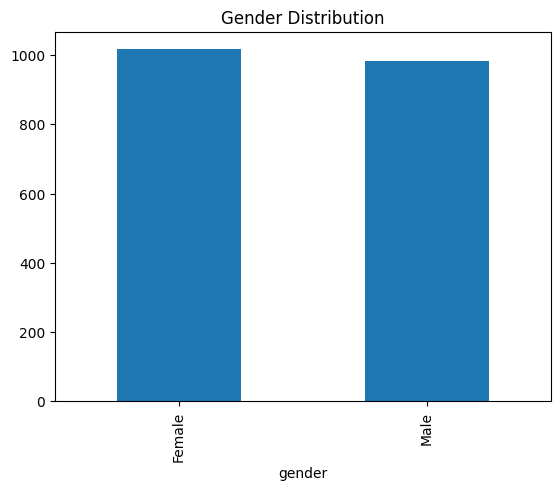

In [32]:
users['gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")

plt.show()

## Credit Score Analysis

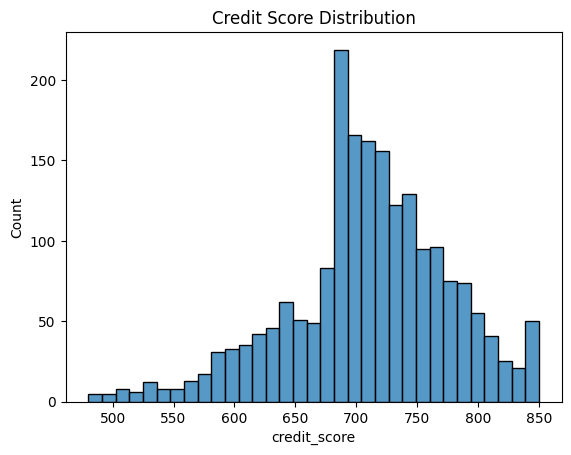

In [33]:
sns.histplot(users['credit_score'])

plt.title("Credit Score Distribution")

plt.show()

## Income Distribution

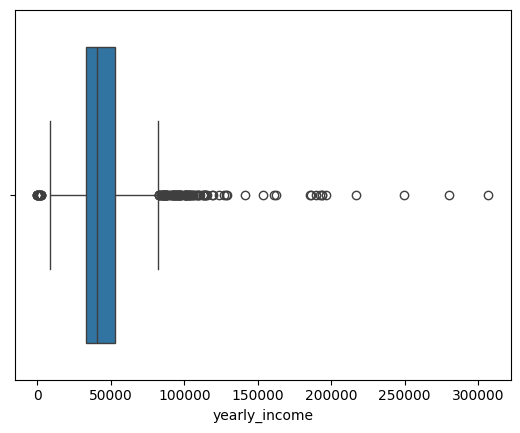

In [34]:
sns.boxplot(x=users['yearly_income'])

plt.show()

## Transaction Distribution

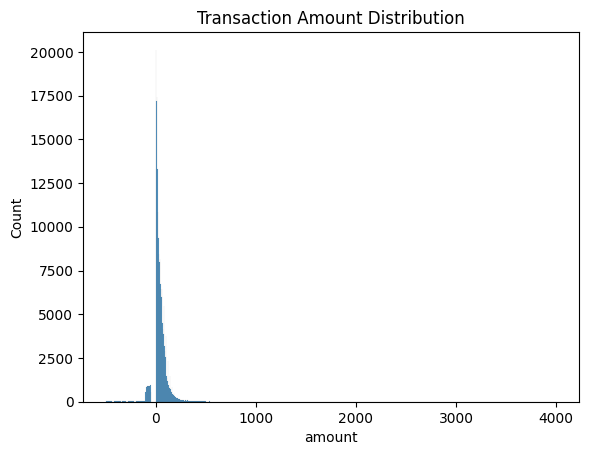

In [35]:
sns.histplot(transactions['amount'])

plt.title("Transaction Amount Distribution")

plt.show()

## visualization

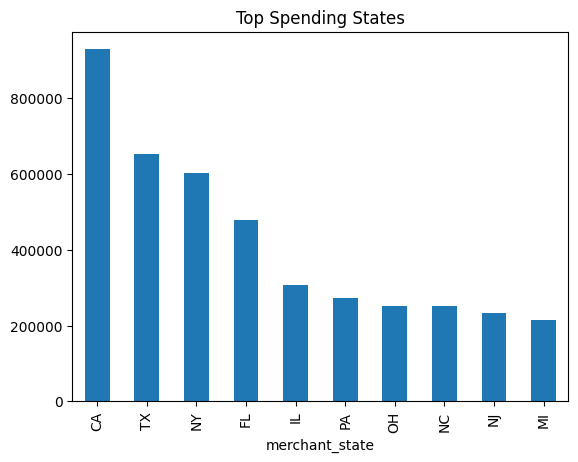

In [36]:
transactions.groupby(
    'merchant_state'
)['amount'].sum().sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Spending States")

plt.show()

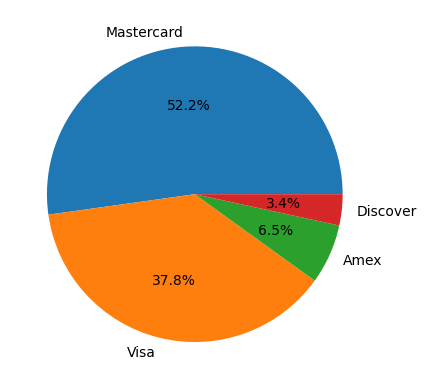

In [37]:
cards['card_brand'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

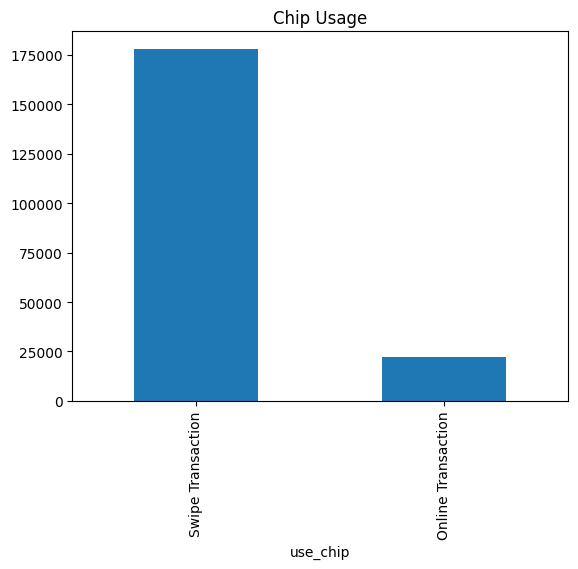

In [38]:
transactions['use_chip'].value_counts().plot(
    kind='bar'
)

plt.title("Chip Usage")

plt.show()

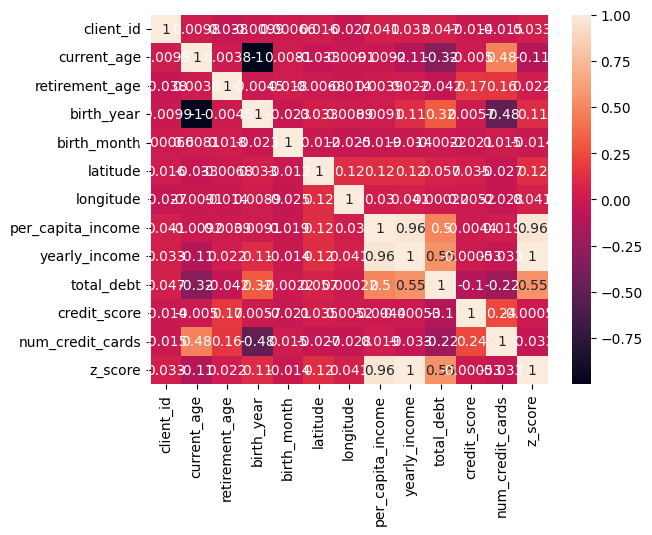

In [39]:
sns.heatmap(
    numeric_data.corr(),
    annot=True
)

plt.show()

## Gaussian Distribution Plot

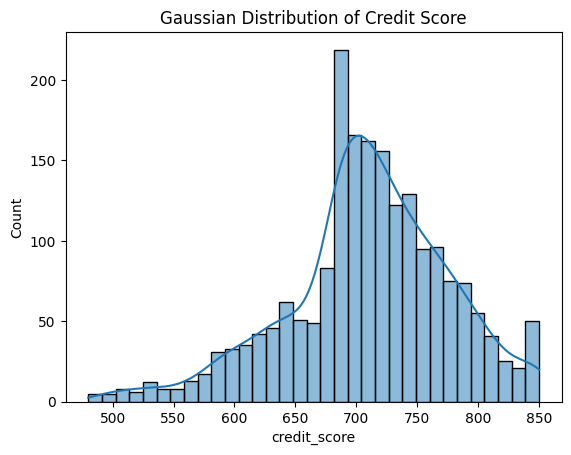

In [11]:
sns.histplot(
    users['credit_score'],
    kde=True
)

plt.title("Gaussian Distribution of Credit Score")

plt.show()

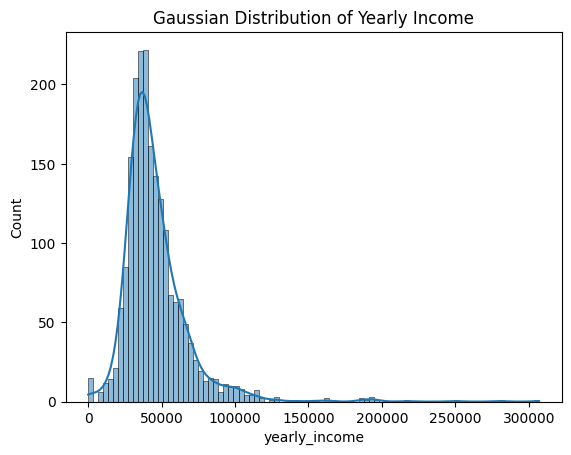

In [12]:
sns.histplot(
    users['yearly_income'],
    kde=True
)

plt.title("Gaussian Distribution of Yearly Income")

plt.show()